In [52]:
#Import required libraries
import numpy as np  # For numerical and matrix operations
import pandas as pd  # For csv operations(read/write) and data manipulation
import matplotlib.pyplot as plt  # For plotting graph 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler # For Encoding and standardization 

In [53]:
df = pd.read_csv("customers data.csv")
df.head()  # Shows first 5 rows of dataframe

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,City,Review_Text,Membership_Duration,Purchase_Frequency,Satisfaction_Rating,...,Engagement_Score,Customer_Segment,City_Tier,Review_Length,Positive_Feedback,Avg_Spend_per_Visit,Loyalty_Index,Has_Long_Membership,Digital_Engagement,Churn(target)
0,1,NaN,Male,167717.0,1.0,Kolkata,Loved it,NaN,18.0,4.0,...,7.954019,A,Tier 1,8.0,1.0,80.702928,7.105004,1.0,0.343012,0
1,2,24.0,Female,NaN,19.0,Kolkata,Could be better,1.0,12.0,5.0,...,8.295242,D,Tier 3,15.0,1.0,367.854516,5.496280,0.0,NaN,0
2,3,31.0,Female,82665.0,53.0,Mumbai,Average quality,NaN,12.0,3.0,...,2.303669,B,Tier 1,15.0,0.0,716.858583,8.463902,NaN,0.635137,0
3,4,21.0,Other,113860.0,NaN,Mumbai,Not satisfied,9.0,13.0,2.0,...,5.944107,D,Tier 1,13.0,NaN,516.842167,5.948552,1.0,0.604716,0
4,5,58.0,Other,122489.0,98.0,Delhi,Not satisfied,6.0,4.0,4.0,...,7.189125,A,Tier 1,13.0,1.0,8988.662554,9.154944,1.0,0.464090,0


In [54]:
df.shape  # Show rows*columns of dataframe

(1405, 25)

In [55]:
df.info()  # Shows null values and data type of dataframe features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1405 entries, 0 to 1404
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               1405 non-null   int64  
 1   Age                       1294 non-null   float64
 2   Gender                    1301 non-null   object 
 3   Annual_Income             1291 non-null   float64
 4   Spending_Score            1291 non-null   float64
 5   City                      1309 non-null   object 
 6   Review_Text               1292 non-null   object 
 7   Membership_Duration       1306 non-null   float64
 8   Purchase_Frequency        1301 non-null   float64
 9   Satisfaction_Rating       1300 non-null   float64
 10  Income_to_Spending_Ratio  1292 non-null   float64
 11  Age_Group                 1299 non-null   object 
 12  Is_High_Spender           1295 non-null   float64
 13  Income_Category           1288 non-null   object 
 14  Purchase

In [56]:
df.describe()  # Display Statictics of dataframe

,Customer_ID,Age,Annual_Income,Spending_Score,Membership_Duration,Purchase_Frequency,Satisfaction_Rating,Income_to_Spending_Ratio,Is_High_Spender,Purchase_Intensity,Engagement_Score,Review_Length,Positive_Feedback,Avg_Spend_per_Visit,Loyalty_Index,Has_Long_Membership,Digital_Engagement,Churn(target)
count,1405.000000,1294.000000,1291.000000,1291.000000,1306.000000,1301.000000,1300.000000,1292.000000,1295.000000,1297.000000,1282.000000,1300.000000,1289.000000,1288.000000,1294.000000,1291.000000,1300.000000,1405.000000
mean,989.987900,43.653014,107443.144849,50.446166,4.943338,10.285934,2.993846,4459.065538,0.305019,51.751041,5.544625,11.449231,0.611327,2761.176434,5.515818,0.440744,0.509410,0.281851
std,576.096321,15.055998,52110.972179,28.369940,2.585519,5.579608,1.414744,8941.458892,0.460593,43.166583,2.622762,2.878559,0.487638,2196.453659,2.526876,0.496669,0.289936,0.450061
min,1.000000,18.000000,20028.000000,1.000000,1.000000,1.000000,1.000000,240.055556,0.000000,0.100000,1.000084,8.000000,0.000000,12.534849,1.019564,0.000000,0.000400,0.000000
25%,503.000000,30.000000,61197.500000,26.000000,3.000000,5.000000,2.000000,1185.995155,0.000000,16.200000,3.299225,8.000000,0.000000,926.165509,3.443992,0.000000,0.257344,0.000000
50%,981.000000,44.000000,107924.000000,51.000000,5.000000,10.000000,3.000000,2089.509221,0.000000,39.200000,5.510021,12.000000,1.000000,2157.132593,5.601395,0.000000,0.506496,0.000000
75%,1484.000000,57.000000,153307.500000,76.000000,7.000000,15.000000,4.000000,4016.380556,1.000000,78.400000,7.824266,15.000000,1.000000,4140.658986,7.681297,1.000000,0.770507,1.000000
max,1999.000000,69.000000,199845.000000,99.000000,9.000000,19.000000,5.000000,94872.000000,1.000000,188.100000,9.997253,15.000000,1.000000,9495.145151,9.989347,1.000000,0.999697,1.000000


In [57]:
df.isnull().sum()  # Checking for null values

Customer_ID                   0
Age                         111
Gender                      104
Annual_Income               114
Spending_Score              114
City                         96
Review_Text                 113
Membership_Duration          99
Purchase_Frequency          104
Satisfaction_Rating         105
Income_to_Spending_Ratio    113
Age_Group                   106
Is_High_Spender             110
Income_Category             117
Purchase_Intensity          108
Engagement_Score            123
Customer_Segment            122
City_Tier                    96
Review_Length               105
Positive_Feedback           116
Avg_Spend_per_Visit         117
Loyalty_Index               111
Has_Long_Membership         114
Digital_Engagement          105
Churn(target)                 0
dtype: int64

In [58]:
print("Duplicate Value Exist: ", df.duplicated().any())
print("Duplicate value count: ", df.duplicated().sum())

Duplicate Value Exist:  True
Duplicate value count:  3


In [59]:
print("Duplicate values: ")
df[df.duplicated()]  # Display duplicate data

Duplicate values: 


,Customer_ID,Age,Gender,Annual_Income,Spending_Score,City,Review_Text,Membership_Duration,Purchase_Frequency,Satisfaction_Rating,...,Engagement_Score,Customer_Segment,City_Tier,Review_Length,Positive_Feedback,Avg_Spend_per_Visit,Loyalty_Index,Has_Long_Membership,Digital_Engagement,Churn(target)
14,14,61.0,Male,40863.0,59.0,Chennai,Good product,1.0,17.0,5.0,...,2.468259,C,NaN,NaN,1.0,2839.195917,4.834711,0.0,0.075551,0
83,107,24.0,Male,117064.0,98.0,Delhi,Not satisfied,5.0,10.0,4.0,...,NaN,A,Tier 3,13.0,1.0,NaN,1.669299,0.0,0.279105,0
104,134,63.0,Male,135260.0,71.0,Bangalore,Good product,6.0,19.0,4.0,...,3.999986,B,Tier 3,12.0,1.0,6273.773709,4.329156,1.0,0.091369,0


In [60]:
df = df.drop_duplicates(subset=['Customer_ID'])  # Drop duplicate data

In [61]:
# Dropping unnecessary features

df.drop(['Customer_ID', 'Income_to_Spending_Ratio', 'Age_Group',
         'Is_High_Spender', 'Income_Category', 'Review_Text',
         'Review_Length', 'Positive_Feedback', 'City_Tier'],
        axis=1, inplace=True)

In [62]:
# Filling null values with mean / mode / median

# Selecting features with null values
cols_to_fill = {  
    'Age': 'mean',
    'Annual_Income': 'median',  
    'Spending_Score': 'mean',  
    'Purchase_Frequency': 'mean', 
    'Satisfaction_Rating': 'mode',  
    'Purchase_Intensity': 'mean',  
    'Engagement_Score': 'mean',  
    'Customer_Segment': 'mode',  
    'Avg_Spend_per_Visit': 'mean',  
    'Loyalty_Index': 'mean',  
    'Has_Long_Membership': 'mode', 
    'Digital_Engagement': 'mean'  
}

# Loop to fill null values of selected features
for col, method in cols_to_fill.items():  
    if col not in df.columns:  
        continue   
    if method == 'mean':  
        df[col].fillna(df[col].mean(), inplace=True)  
    elif method == 'median':  
        df[col].fillna(df[col].median(), inplace=True)  
    elif method == 'mode':  
        df[col].fillna(df[col].mode()[0], inplace=True) 


C:\Users\Deepak\AppData\Local\Temp\ipykernel_6104\606247310.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\Deepak\AppData\Local\Temp\ipykernel_6104\606247310.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [63]:
# Changing data types from float to integer
for col in ['Age', 'Spending_Score', 'Purchase_Frequency', 'Satisfaction_Rating', 'Has_Long_Membership']:  
    df[col] = df[col].astype(int)

In [64]:
# Filling null values of Gender with 'Not specified'
df['Gender'] = df['Gender'].fillna('Not specified')
df['Gender'].unique()

array(['Male', 'Female', 'Other', 'Not specified'], dtype=object)

In [65]:
# Filling null values of City with 'Unknows'
df['City'] = df['City'].fillna('Unknown')

In [66]:
# Fill Membership Dutation null values and change data type
df['Membership_Duration'] = df['Membership_Duration'].fillna('0')
df['Membership_Duration'] = df['Membership_Duration'].astype(int)

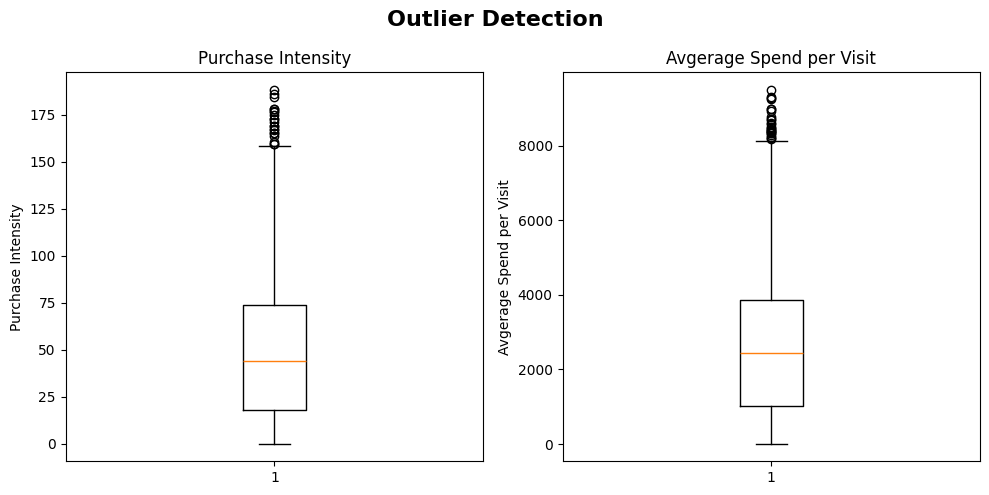

In [67]:
# Plotting a plot for outlier detection
fig, (plt1, plt2) = plt.subplots(1, 2, figsize=(10, 5)) 

plt1.boxplot(df['Purchase_Intensity'])  
plt1.set_title('Purchase Intensity')  
plt1.set_ylabel('Purchase Intensity') 

plt2.boxplot(df['Avg_Spend_per_Visit']) 
plt2.set_title('Avgerage Spend per Visit')
plt2.set_ylabel('Avgerage Spend per Visit') 

plt.suptitle('Outlier Detection', fontsize=16, fontweight='bold') 
plt.tight_layout()  
plt.show()  


In [68]:
# Removing outilers
df = df[(df['Purchase_Intensity'] >= 0) & (df['Purchase_Intensity'] <= 145)]  
df = df[(df['Avg_Spend_per_Visit'] >= 0) & (df['Avg_Spend_per_Visit'] <= 7500)]

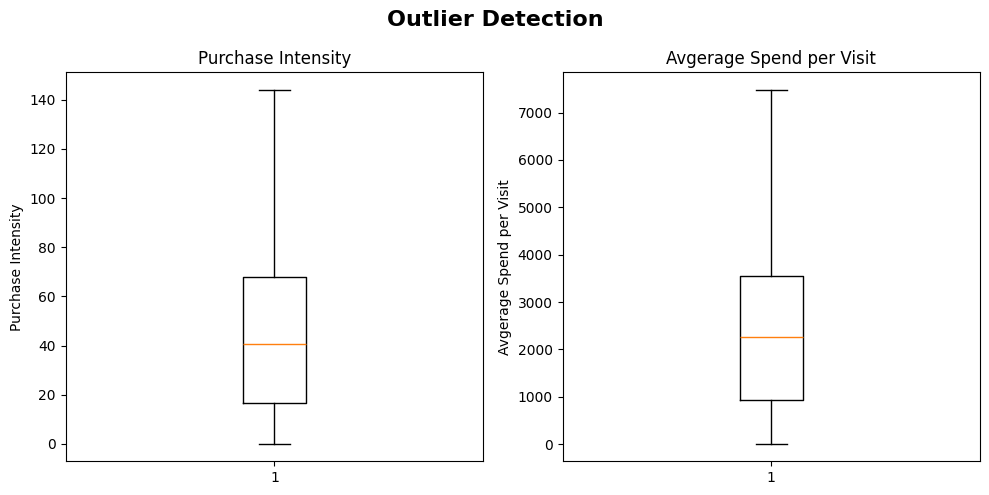

In [69]:
fig, (plt1, plt2) = plt.subplots(1, 2, figsize=(10, 5))  

plt1.boxplot(df['Purchase_Intensity'])  
plt1.set_title('Purchase Intensity')  
plt1.set_ylabel('Purchase Intensity') 

plt2.boxplot(df['Avg_Spend_per_Visit']) 
plt2.set_title('Avgerage Spend per Visit') 
plt2.set_ylabel('Avgerage Spend per Visit') 

plt.suptitle('Outlier Detection', fontsize=16, fontweight='bold') 
plt.tight_layout()  
plt.show()  


In [70]:
# Feature Enginnering - creating new features using current features
df['Spending_Efficiency'] = df['Spending_Score'] / df['Annual_Income']  
df['Engagement_Ratio'] = df['Digital_Engagement'] * df['Engagement_Score']  
df['Loyalty_Duration_Interaction'] = df['Membership_Duration'] * df['Loyalty_Index']  

In [71]:
# Label encoding categorical features
le = LabelEncoder()  
df['Gender'] = le.fit_transform(df['Gender'])  
df['City'] = le.fit_transform(df['City'])  
df['Customer_Segment'] = le.fit_transform(df['Customer_Segment'])  

In [72]:
# Standardize data
scaler = StandardScaler()  

cols_to_scale = ['Age', 'Annual_Income','Spending_Score', 'Membership_Duration', 'Purchase_Frequency',  
                'Satisfaction_Rating', 'Purchase_Intensity', 'Engagement_Score', 'Avg_Spend_per_Visit', 'Loyalty_Index',  
                'Digital_Engagement', 'Spending_Efficiency', 'Engagement_Ratio', 'Loyalty_Duration_Interaction']  

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])  

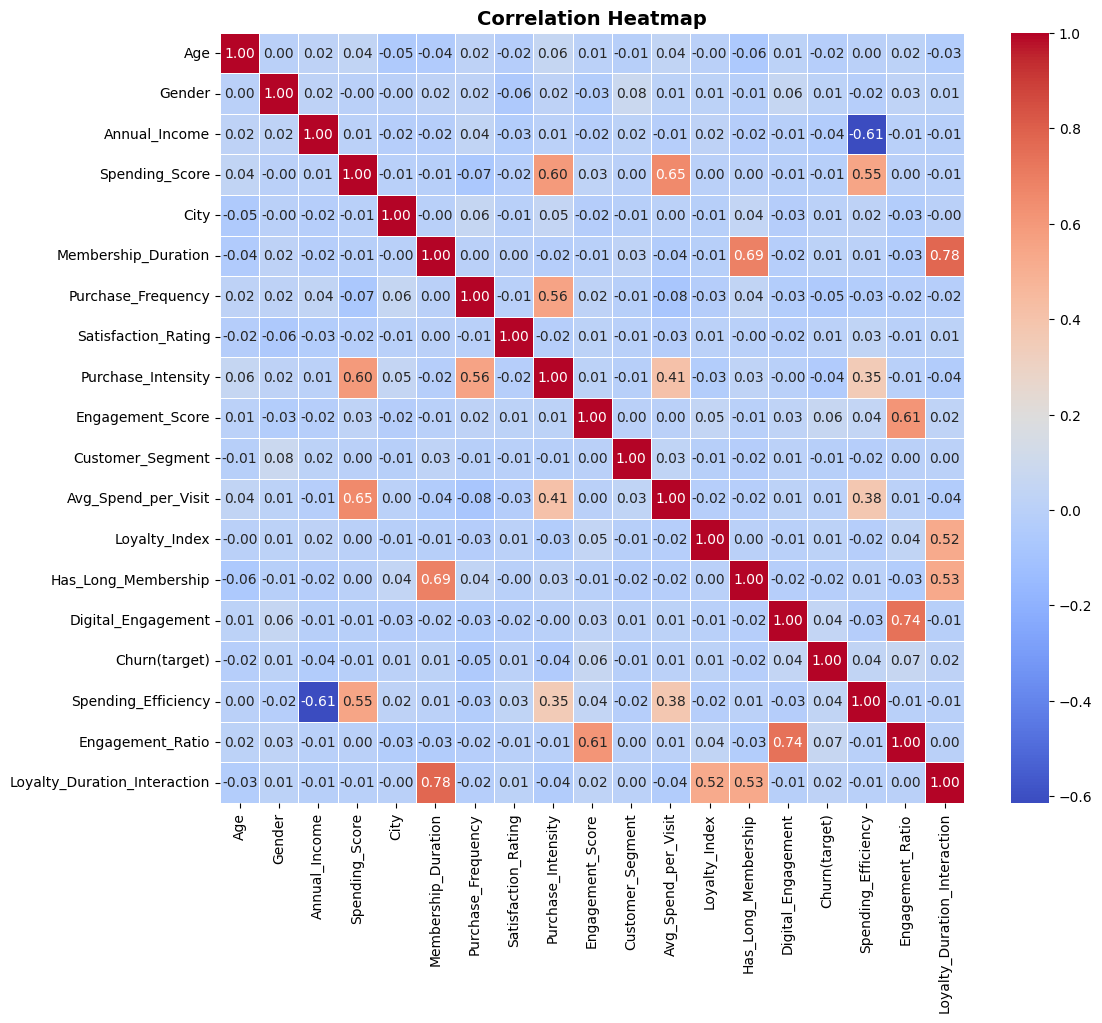

In [73]:
# Correlation heatmap to show relation between features and target
corr = df.corr(numeric_only=True)  
plt.figure(figsize=(12, 10))  
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)  
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')  
plt.show()  

In [74]:
# Dropping features
df.drop(['Spending_Score', 'Digital_Engagement', 'Engagement_Score', 'Membership_Duration', 'Loyalty_Index'], axis=1, inplace=True)  

In [75]:
print("Final data shape: ",df.shape)

Final data shape:  (1317, 14)


In [78]:
# Save cleaned data to new csv file
df.to_csv('cleaned_customers_data.csv')